# Feature space Notebook

In [3]:
# Feature Space Creation (Respiratory Cultures)
#
# This notebook builds the feature space for respiratory infection ICU admissions.
#
# Decisions:
# - Index time: first respiratory culture per hadm_id.
# - Label: keep raw AST interpretation (S/I/R) per antibiotic.
# - Feature window: admittime <= event_time <= index_time.
#
# Notes: run cells from top to bottom.


In [4]:
%%ai

UsageError: Cell magic `%%ai` not found.


In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import tools.helpers as hh  
import tools.visualisers_ as vv

DATA_ROOT = Path("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building")
PARQ_DIR = DATA_ROOT / "parq"
OUTPUT_DIR = DATA_ROOT / "outputs"

In [6]:
import importlib
importlib.reload(vv)

<module 'tools.visualisers_' from '/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/visualisers_.py'>

# Functions

In [7]:
def ensure_datetime(series, unix_unit=None):
    """
    Strict conversion of Series to datetime.
    Raises error if conversion fails.
    """

    if pd.api.types.is_numeric_dtype(series):
        if unix_unit is None:
            raise ValueError(
                "Numeric datetime detected. Please specify unix_unit ('s', 'ms', etc.)"
            )
        return pd.to_datetime(series, unit=unix_unit)

    # For non-numeric types: raise error if parsing fails
    return pd.to_datetime(series, errors="raise")


In [8]:
def filter_events_by_time_window(
    anchor_df,
    events_df,
    id_col,
    anchor_time_col,
    event_time_col,
    time_window,
    unix_unit=None,   # optional: 's' or 'ms'
):
    if not (isinstance(time_window, (list, tuple)) and len(time_window) == 2):
        raise ValueError("time_window must be [start_hour, end_hour]")

    start_hr, end_hr = time_window

    anchor_df = anchor_df[[id_col, anchor_time_col]].copy()
    events_df = events_df.copy()

    anchor_df[anchor_time_col] = ensure_datetime(
        anchor_df[anchor_time_col], unix_unit
    )

    events_df[event_time_col] = ensure_datetime(
        events_df[event_time_col], unix_unit
    )

    merged = events_df.merge(anchor_df, on=id_col, how="inner")

    lower = merged[anchor_time_col] + pd.to_timedelta(start_hr, unit="h")
    upper = merged[anchor_time_col] + pd.to_timedelta(end_hr, unit="h")

    mask = (
        (merged[event_time_col] >= lower) &
        (merged[event_time_col] <= upper)
    )

    return merged.loc[mask].drop(columns=[anchor_time_col])


In [9]:
# !pip install jupyterlab>=4.0
!pip install "jupyter-ai[all]"


  Using cached jupyter_ai-2.31.7-py3-none-any.whl.metadata (8.3 kB)
  Using cached dask-2026.1.2-py3-none-any.whl.metadata (3.8 kB)
  Using cached deepmerge-2.0-py3-none-any.whl.metadata (3.5 kB)
  Using cached faiss_cpu-1.13.2-cp310-abi3-macosx_14_0_arm64.whl.metadata (7.6 kB)
  Using cached importlib_metadata-8.7.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached jupyter_ai_magics-2.31.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached arxiv-2.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached jsonpath_ng-1.7.0-py3-none-any.whl.metadata (18 kB)
  Using cached langchain_community-0.3.31-py3-none-any.whl.metadata (3.0 kB)
  Using cached langchain-0.3.27-py3-none-any.whl.metadata (7.8 kB)
  Using cached langchain_core-0.3.83-py3-none-any.whl.metadata (3.2 kB)
  Using cached langchain_text_splitters-0.3.11-py3-none-any.whl.metadata (1.8 kB)
  Using cached re

In [10]:
def filter_events_between_anchors(
    start_anchor_df,
    end_anchor_df,
    events_df,
    id_col,
    start_time_col,
    end_time_col,
    event_time_col,
    unix_unit=None,
):
    """
    Filter events_df to keep events occurring between two anchor datetimes.
    """

    # Copy required columns
    start_anchor_df = start_anchor_df[[id_col, start_time_col]].copy()
    end_anchor_df = end_anchor_df[[id_col, end_time_col]].copy()
    events_df = events_df.copy()

    # Convert to datetime using external helper
    start_anchor_df[start_time_col] = ensure_datetime(
        start_anchor_df[start_time_col], unix_unit
    )

    end_anchor_df[end_time_col] = ensure_datetime(
        end_anchor_df[end_time_col], unix_unit
    )

    events_df[event_time_col] = ensure_datetime(
        events_df[event_time_col], unix_unit
    )

    # Merge anchors into events
    merged = (
        events_df
        .merge(start_anchor_df, on=id_col, how="inner")
        .merge(end_anchor_df, on=id_col, how="inner")
    )

    # Filter between anchors
    mask = (
        (merged[event_time_col] >= merged[start_time_col]) &
        (merged[event_time_col] <= merged[end_time_col])
    )

    return merged.loc[mask].drop(columns=[start_time_col, end_time_col])


In [11]:
# Filter meds taken at least N times or for N days per ID

def filter_meds_by_frequency(
    df,
    id_col,
    med_col,
    time_col=None,
    min_count=2,
    min_days=2,
    use_or=True,
):
    """
    Return rows where a medication is taken at least min_count times
    OR for at least min_days distinct days (if time_col provided).

    - df: input dataframe
    - id_col: column for patient/admission/stay ID
    - med_col: medication/drug column
    - time_col: datetime column (optional)
    - min_count: minimum number of rows per ID+med
    - min_days: minimum distinct days per ID+med (requires time_col)
    - use_or: if True, keep rows meeting count OR days; else AND
    """
    work = df.copy()
    base = work[[id_col, med_col]].copy()
    base["_count"] = 1

    # Count occurrences per ID+med
    counts = base.groupby([id_col, med_col], dropna=False)["_count"].sum()
    counts = counts.rename("occurrences")

    if time_col is not None:
        dates = pd.to_datetime(work[time_col], errors="coerce").dt.normalize()
        days = (
            pd.DataFrame({id_col: work[id_col], med_col: work[med_col], "_date": dates})
            .dropna(subset=["_date"])
            .groupby([id_col, med_col], dropna=False)["_date"]
            .nunique()
            .rename("days")
        )
    else:
        days = None

    stats = counts.to_frame()
    if days is not None:
        stats = stats.join(days, how="left")
        stats["days"] = stats["days"].fillna(0)

    if use_or:
        if days is not None:
            keep = (stats["occurrences"] >= min_count) | (stats["days"] >= min_days)
        else:
            keep = stats["occurrences"] >= min_count
    else:
        if days is not None:
            keep = (stats["occurrences"] >= min_count) & (stats["days"] >= min_days)
        else:
            keep = stats["occurrences"] >= min_count

    keep_index = keep[keep].index
    mask = pd.MultiIndex.from_frame(work[[id_col, med_col]]).isin(keep_index)
    return work.loc[mask].copy()


# Example:
# med_col = pick_col(resp_emar, ["medication", "drug", "drug_name"])
# time_col = pick_col(resp_emar, ["charttime", "starttime", "storetime"])
# resp_emar_filtered = filter_meds_by_frequency(
#     resp_emar,
#     id_col="hadm_id",
#     med_col=med_col,
#     time_col=time_col,
#     min_count=2,
#     min_days=2,
# )

In [12]:
# Utility: remove rows by list of values in a column
#
# How to use:
# clean_df = remove_rows_by_list(
#     df,
#     col="medication",
#     values=["heparin", "saline"],
#     case_insensitive=True,
# )

def remove_rows_by_list(df, col, values, case_insensitive=True):
    """
    Remove rows where df[col] matches any value in values.

    - case_insensitive: if True, compares upper-cased strings
    """
    work = df.copy()
    series = work[col].astype(str)

    if case_insensitive:
        series_cmp = series.str.upper()
        values_cmp = {str(v).upper() for v in values}
    else:
        series_cmp = series
        values_cmp = {str(v) for v in values}

    mask = series_cmp.isin(values_cmp)
    return work.loc[~mask].copy()

In [13]:
# Utility: find rows by list of values in a column
#
# How to use:
# matched_df = find_rows_by_list(
#     df,
#     col="medication",
#     values=["heparin", "saline"],
#     case_insensitive=True,
# )

def find_rows_by_list(df, col, values, case_insensitive=True):
    """
    Return rows where df[col] matches any value in values.

    - case_insensitive: if True, compares upper-cased strings
    """
    work = df.copy()
    series = work[col].astype(str)

    if case_insensitive:
        series_cmp = series.str.upper()
        values_cmp = {str(v).upper() for v in values}
    else:
        series_cmp = series
        values_cmp = {str(v) for v in values}

    mask = series_cmp.isin(values_cmp)
    return work.loc[mask].copy()

In [14]:
def venn_for_dfs(dfs, key_cols=None, labels=None, ax=None):
    """Plot a Venn diagram for 2 or 3 dataframes.

    - dfs: list/tuple of 2 or 3 dataframes
    - key_cols: None, a single column name, or list of column names (per df)
    - labels: list/tuple of labels (per df)

    If a key col is None, uses the index values for that df.
    Returns a dict of set overlap counts.
    """
    if not isinstance(dfs, (list, tuple)):
        raise ValueError("dfs must be a list/tuple of 2 or 3 dataframes")
    if len(dfs) not in (2, 3):
        raise ValueError("dfs must contain exactly 2 or 3 dataframes")

    n = len(dfs)

    if key_cols is None:
        key_cols = [None] * n
    elif isinstance(key_cols, str):
        key_cols = [key_cols] * n
    elif len(key_cols) != n:
        raise ValueError("key_cols must match number of dataframes")

    if labels is None:
        labels = ["df{}".format(i + 1) for i in range(n)]
    elif len(labels) != n:
        raise ValueError("labels must match number of dataframes")

    def to_set(df, col):
        if col is None:
            keys = pd.Index(df.index).dropna().unique()
        else:
            keys = pd.Index(df[col].dropna().unique())
        return set(keys)

    sets = [to_set(dfs[i], key_cols[i]) for i in range(n)]

    if n == 2:
        left_set, right_set = sets
        counts = {
            "only_left": len(left_set - right_set),
            "only_right": len(right_set - left_set),
            "overlap": len(left_set & right_set),
        }
        try:
            from matplotlib_venn import venn2
            import matplotlib.pyplot as plt

            if ax is None:
                _, ax = plt.subplots(figsize=(4, 4))
            venn2([left_set, right_set], set_labels=labels, ax=ax)
            ax.set_title("Venn: {} vs {}".format(labels[0], labels[1]))
        except Exception:
            # If matplotlib_venn is unavailable, return counts only.
            pass
        return counts

    a_set, b_set, c_set = sets
    counts = {
        "only_a": len(a_set - b_set - c_set),
        "only_b": len(b_set - a_set - c_set),
        "only_c": len(c_set - a_set - b_set),
        "overlap_ab": len((a_set & b_set) - c_set),
        "overlap_ac": len((a_set & c_set) - b_set),
        "overlap_bc": len((b_set & c_set) - a_set),
        "overlap_abc": len(a_set & b_set & c_set),
    }

    try:
        from matplotlib_venn import venn3
        import matplotlib.pyplot as plt

        if ax is None:
            , ax = plt.subplots(figsize=(4, 4))
        venn3([a_set, b_set, c_set], set_labels=labels, ax=ax)
        ax.set_title("Venn: {} vs {} vs {}".format(labels[0], labels[1], labels[2]))
    except Exception:
        # If matplotlib_venn is unavailable, return counts only.
        pass

    return counts


In [15]:
def column_coverage_by_id(df, lab_col, id_col):
    """
    Compute patient-level coverage of each value in a column.

    Parameters
    ----------
    df : pd.DataFrame
    lab_col : str
        Column with categories (e.g., lab_name)
    id_col : str
        Patient identifier (e.g., pid, subject_id)

    Returns
    -------
    pd.DataFrame
        value | n_patients | coverage
    """
    total_patients = df[id_col].nunique()

    coverage_df = (
        df[[id_col, lab_col]]
        .drop_duplicates()
        .value_counts(lab_col)
        .reset_index(name="n_patients")
    )

    coverage_df["coverage"] = coverage_df["n_patients"] / total_patients

    return coverage_df.sort_values("coverage", ascending=False)


In [16]:



def lab_stats_per_patient(
    df,
    id_col,
    lab_col,
    value_col,
    stats=("mean", "median", "min", "max"),
):
    """
    Compute patient-level lab statistics per lab.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe (e.g., labevents)
    id_col : str
        Patient identifier (e.g., subject_id)
    lab_col : str
        Lab identifier (e.g., itemid or lab_name)
    value_col : str
        Numeric lab value (e.g., valuenum)
    stats : iterable of str
        Statistics to compute. Allowed: mean, median, min, max

    Returns
    -------
    pd.DataFrame
        One row per (patient, lab) with requested statistics
    """

    stat_map = {
        "mean": "mean",
        "median": "median",
        "min": "min",
        "max": "max",
    }

    invalid = set(stats) - stat_map.keys()
    if invalid:
        raise ValueError(f"Unsupported stats requested: {invalid}")

    agg_dict = {value_col: [stat_map[s] for s in stats]}

    out = (
        df
        .dropna(subset=[value_col])
        .groupby([id_col, lab_col])
        .agg(agg_dict)
    )

    # flatten column names
    out.columns = [
        f"{value_col}_{stat}" for stat in stats
    ]

    return out.reset_index()

In [17]:


def lab_stats_per_patient_with_coverage(
    df,
    id_col,
    lab_col,
    value_col,
    stats=("mean", "median", "min", "max"),
    min_coverage=None,  # e.g. 0.3 for 30%
):
    """
    Compute patient-level lab statistics per lab,
    optionally filtering labs by patient-level coverage.

    Parameters
    ----------
    df : pd.DataFrame
    id_col : str
        Patient identifier
    lab_col : str
        Lab identifier
    value_col : str
        Numeric lab value
    stats : iterable of str
        Statistics to compute
    min_coverage : float or None
        Minimum patient coverage required (e.g., 0.3 = 30%)

    Returns
    -------
    pd.DataFrame
        One row per (patient, lab) with requested statistics
    """

    # ---- stats validation ----
    if isinstance(stats, str):
        stats = [stats]

    stat_map = {
        "mean": "mean",
        "median": "median",
        "min": "min",
        "max": "max",
    }

    invalid = set(stats) - stat_map.keys()
    if invalid:
        raise ValueError(f"Unsupported stats requested: {invalid}")

    df = df.copy()
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

    # ---- coverage filtering ----
    if min_coverage is not None:
        coverage_df = column_coverage_by_id(
            df=df,
            lab_col=lab_col,
            id_col=id_col,
        )

        valid_labs = coverage_df.loc[
            coverage_df["coverage"] >= min_coverage,
            lab_col,
        ]

        df = df[df[lab_col].isin(valid_labs)]

    # ---- aggregation ----
    out = (
        df
        .dropna(subset=[value_col])
        .groupby([id_col, lab_col])[value_col]
        .agg(stats)
        .reset_index()
    )

    return out


# Load Cohorts

In [18]:
# Load core datasets for the respiratory infection ICU cohort
resp_inf_cohort = pd.read_parquet(PARQ_DIR / "resp_inf_cohort_23Jan26_1953.parquet")
df_resp_inf_icu_final = pd.read_parquet(PARQ_DIR / "df_resp_inf_icu_final.parq")

# Microbiology, medications, prescriptions, inputs, and labs
resp_micro = pd.read_parquet(PARQ_DIR / "resp_micro_hosp_icu_inf_df_23Jan26_2050.parquet")
resp_emar = pd.read_parquet(PARQ_DIR / "resp_emar_hosp_icu_inf_results_df_24Jan26_0507.parquet")
resp_pres = pd.read_parquet(PARQ_DIR / "resp_pres_hosp_icu_inf_results_df24Jan26_0526.parquet")
resp_input = pd.read_parquet(PARQ_DIR / "resp_inputevents_icu_inf_results_df.parquet")
resp_lab = pd.read_parquet(PARQ_DIR / "resp_lab_test_icu_inf_df.parq")


In [19]:
hh.dxx(resp_inf_cohort)
hh.dxx(df_resp_inf_icu_final)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,4055 | 14054,18109 | 0,18109 | 0,18099 | 10,18099 | 10,18109 | 0,18109 | 0,18074 | 35,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33,38,2,142
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE,3,10,J1289
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE,2,10,J1282
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN,2,10,J15212


11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 6)



,subject_id,hadm_id,stay_id,seq_num,icd_version,icd_code
dtype,int64,int64,int64,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,13611,16438,38,2,142
0,10001843,26133978,39698942,4,10,J189
1,10001884,26184834,37510196,19,10,J0190
2,10002155,20345487,32358465,2,9,486


## Histograms

In [21]:
stays_per_admission = (df_resp_inf_icu_final.groupby("hadm_id")["stay_id"].nunique().rename("n_stays"))


In [22]:
stays_per_admission.value_counts()

n_stays
1     11384
2      1788
3       333
4        73
5        20
6         9
7         2
9         1
10        1
Name: count, dtype: int64

<Axes: >

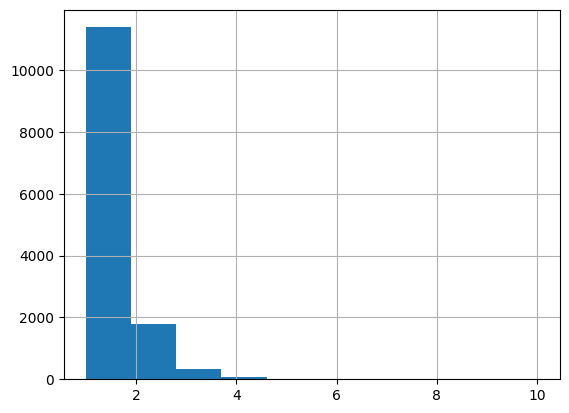

In [23]:
stays_per_admission.hist()

In [24]:
admissions_per_subject = (df_resp_inf_icu_final.groupby("subject_id")["hadm_id"].nunique().rename("n_admissions"))


In [25]:
admissions_per_subject.value_counts()

n_admissions
1     10682
2       947
3       183
4        45
5        22
6        14
7         5
9         3
8         2
18        1
16        1
Name: count, dtype: int64

<Axes: >

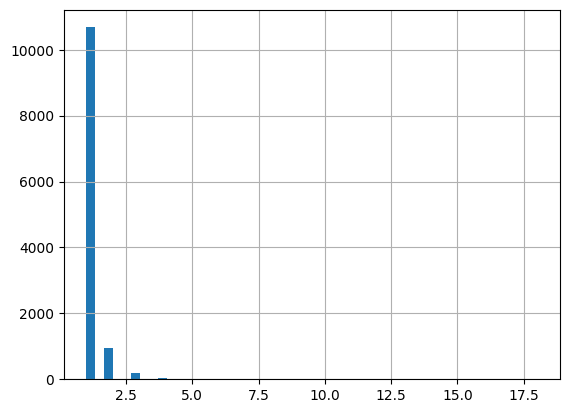

In [26]:
admissions_per_subject.hist(bins= 50)

In [27]:
hh.dx(resp_micro)
hh.dx(resp_emar)
hh.dx(resp_pres)
hh.dx(resp_input)
hh.dx(resp_lab)

11.3k Unique Patient IDs (11348)
12.9k Unique Admission IDs (12922)
15.7k Unique ICU Stay IDs (15723)
421.7k Rows, shape: (421739, 18)

7.5k Unique Patient IDs (7511)
8.4k Unique Admission IDs (8356)
10.3k Unique ICU Stay IDs (10324)
15.9M Rows, shape: (15923208, 19)

11.9k Unique Patient IDs (11870)
13.6k Unique Admission IDs (13570)
16.4k Unique ICU Stay IDs (16391)
2.9M Rows, shape: (2897824, 23)

10.6k Unique Patient IDs (10617)
12.2k Unique Admission IDs (12178)
14.5k Unique ICU Stay IDs (14523)
3.6M Rows, shape: (3592872, 26)

11.9k Unique Patient IDs (11864)
13.5k Unique Admission IDs (13549)
ICU Stay ID column not found.
10.9M Rows, shape: (10886372, 18)



In [28]:
lab_test_hosp_icu_df= hh.load_data('./parq/lab_test_hosp_icu_df_23Jan26_2125.parquet')
hh.dx(lab_test_hosp_icu_df)

11.9k Unique Patient IDs (11864)
13.5k Unique Admission IDs (13549)
16.4k Unique ICU Stay IDs (16370)
16.2M Rows, shape: (16160654, 24)



# Analysis

## Resp infection 

### Get the stayid data from admission to culture time 
- first stay 
- define a window of stay

Get the data from admission to 24 hours after AST culture taken


## AST results

In [130]:
ast_df= resp_micro.dropna(subset=["org_name","ab_name","interpretation"])

In [131]:
ast_df.interpretation.value_counts()

interpretation
S    88460
R    34317
I     5024
D       67
Z       31
Name: count, dtype: int64

In [132]:
# ast_df['interpretation'] = ast_df['interpretation'].replace({'I': 'R', 'D': 'R', 'Z': 'R'})


In [133]:
hh.dx(ast_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
127.9k Rows, shape: (127899, 18)



In [33]:
# ast_df.head()

In [34]:
# mapping = {
#     'piperacillin tazobactam': 'piperacillin tazo',
#     'imipenem cilastatin': 'imipenem',
#     'ertapenem sodium': 'ertapenem',
#     'penicillin g potassium': 'penicillin g',
#     'bactrim': 'trimethoprim sulfa'
# }


In [36]:
# ast_df['ab_name']= ast_df.ab_name.apply(normalize_ab)

In [134]:
ast_df['antibiotic'] = ast_df['ab_name'].str.replace(r'\(.*?\)', '', regex=True).str.strip()

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_71260/2595614987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ast_df['antibiotic'] = ast_df['ab_name'].str.replace(r'\(.*?\)', '', regex=True).str.strip()


In [135]:
ast_df['antibiotic'] = ast_df['antibiotic'].replace(mapping)


/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_71260/1216414399.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ast_df['antibiotic'] = ast_df['antibiotic'].replace(mapping)


In [136]:
ast_df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments,antibiotic
4,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5141,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,TRIMETHOPRIM/SULFA,S,1.0,None,TRIMETHOPRIM/SULFA
5,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5142,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,NITROFURANTOIN,R,128.0,None,NITROFURANTOIN
6,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5143,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,GENTAMICIN,S,1.0,None,GENTAMICIN
7,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5144,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,TOBRAMYCIN,S,1.0,None,TOBRAMYCIN
8,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5145,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,CEFTAZIDIME,S,1.0,None,CEFTAZIDIME


In [40]:
# Get the first AST collection for each stay_id (sorted by charttime if available)
first_time = (ast_df.sort_values("charttime").groupby("stay_id")["charttime"].first().reset_index())

In [41]:
first_time.head()

,stay_id,charttime
0,30000153,2174-10-04 10:49:00
1,30000484,2136-01-17 14:42:00
2,30003598,2189-03-20 05:33:00
3,30004232,2135-07-31 14:00:00
4,30004391,2153-09-05 14:48:00


In [42]:
hh.dx(ast_df)
ast_first_df = ast_df.merge(first_time, on=["stay_id", "charttime"])
hh.dx(ast_first_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
127.9k Rows, shape: (127899, 19)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
58.4k Rows, shape: (58417, 19)



In [43]:
hh.dx(ast_first_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
58.4k Rows, shape: (58417, 19)



In [44]:
# hh.parq(ast_first_df,'ast_first_df_')

In [45]:
ast_first_df= hh.load_data('./parq/ast_first_df_16Feb26_0415.parquet')

### Features AST

In [46]:
ast_first_df['susceptible'] = (ast_first_df['interpretation'] == 'S').astype(int)

In [47]:
ast_first_df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments,antibiotic,susceptible
0,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5141,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,trimethoprim sulfa,S,1.0,None,trimethoprim sulfa,1
1,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5142,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,nitrofurantoin,R,128.0,None,nitrofurantoin,0
2,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5143,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,gentamicin,S,1.0,None,gentamicin,1
3,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5144,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,tobramycin,S,1.0,None,tobramycin,1
4,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5145,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,ceftazidime,S,1.0,None,ceftazidime,1


In [48]:
ast_features = (
    ast_first_df
        .pivot_table(
            index='stay_id',
            columns='antibiotic',
            values='susceptible',
            fill_value=0
        )
        .reset_index()
)


In [49]:
ast_features.head()

antibiotic,stay_id,amikacin,ampicillin,ampicillin sulbactam,aztreonam,caspofungin,cefazolin,cefepime,cefiderocol,ceftaroline,...,oxacillin,penicillin g,piperacillin,piperacillin tazo,rifampin,tetracycline,tobramycin,trimethoprim sulfa,vancomycin,voriconzaole
0,30000153,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,30000484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,30003598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,30004232,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
4,30004391,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0


### Venn checks

In [50]:
# vv.venn_for_dfs(dfs=[resp_emar,resp_pres], key_cols=["hadm_id"], labels=["emar", "pres"])

In [51]:
hh.dxx(ast_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
127.9k Rows, shape: (127899, 19)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments,antibiotic
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,object,object,object,object,float64,object,object
NotNA | NA,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,127899 | 0,121517 | 6382,78969 | 48930,127899 | 0
nunique,4079,4426,5914,14,14,5914,5914,5900,84584,6889,8419,34,14,136,46,2,26,47,46
4,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5141,2133-10-01 00:00:00,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,TRIMETHOPRIM/SULFA,S,1.000000,None,TRIMETHOPRIM/SULFA
5,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5142,2133-10-01 00:00:00,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,NITROFURANTOIN,R,128.000000,None,NITROFURANTOIN
6,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5143,2133-10-01 00:00:00,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,GENTAMICIN,S,1.000000,None,GENTAMICIN


In [52]:
ast_df.org_name.nunique()

136

In [53]:
ast_df.org_name.value_counts()[0:50]

org_name
STAPH AUREUS COAG +                                28597
ESCHERICHIA COLI                                   20287
PSEUDOMONAS AERUGINOSA                             19364
KLEBSIELLA PNEUMONIAE                              15790
ENTEROCOCCUS SP.                                    4273
SERRATIA MARCESCENS                                 3931
STAPHYLOCOCCUS, COAGULASE NEGATIVE                  3680
ENTEROCOCCUS FAECIUM                                3280
PROTEUS MIRABILIS                                   3242
ENTEROBACTER CLOACAE COMPLEX                        3088
ACINETOBACTER BAUMANNII COMPLEX                     2618
ENTEROBACTER AEROGENES                              2050
KLEBSIELLA OXYTOCA                                  1839
STAPHYLOCOCCUS EPIDERMIDIS                          1681
STENOTROPHOMONAS MALTOPHILIA                        1162
ENTEROBACTER CLOACAE                                1109
STREPTOCOCCUS PNEUMONIAE                             989
CITROBACTER FREUNDII C

In [49]:
hh.dxx(resp_emar)

7.5k Unique Patient IDs (7511)
8.4k Unique Admission IDs (8356)
10.3k Unique ICU Stay IDs (10324)
15.9M Rows, shape: (15923208, 19)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,emar_id,emar_seq,charttime,medication,parent_field_ordinal,administration_type,dose_due,dose_due_unit,dose_given,dose_given_unit,product_code,product_description
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],object,int64,datetime64[ns],object,object,object,object,object,object,object,object,object
NotNA | NA,15923208 | 0,15923208 | 0,15923208 | 0,15923208 | 0,15923208 | 0,15923208 | 0,15910432 | 12776,15923208 | 0,15923208 | 0,15923208 | 0,15221633 | 701575,7914583 | 8008625,8008248 | 7914960,7524283 | 8398925,7960705 | 7962503,6983758 | 8939450,7135557 | 8787651,7351418 | 8571790,5415355 | 10507853
nunique,7511,8356,10324,14,14,10324,10316,5049877,41440,2334260,1886,43,24,2393,182,835,121,1989,3518
0,10004733,27411876,39635619,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2174-12-04 11:28:24,2174-12-12 20:03:01,10004733-447,447,2174-12-26 05:10:00,Clonidine Patch 0.3 mg/24 hr,None,Transdermal Patch,1,PTCH,None,None,None,None
1,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-566,566,2135-01-14 17:08:00,Albuterol Inhaler,1.1,None,None,None,6,PUFF,ALBU17H,Albuterol Inhaler Inhaler
2,10005817,28661809,31316840,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2135-01-03 21:55:32,2135-01-19 21:16:23,10005817-566,566,2135-01-14 17:08:00,Albuterol Inhaler,None,Standard Maintenance Medication,6,PUFF,None,None,None,None


## Antibiotics from medications Input and EMAR

In [54]:
input_ab_df= resp_input[resp_input.ordercategoryname.isin(["08-Antibiotics (IV)","09-Antibiotics (Non IV)"])]

In [55]:
input_ab_df.label.value_counts()

label
Dextrose 5%                        158509
NaCl 0.9%                           58127
Vancomycin                          52066
Cefepime                            35631
Piperacillin/Tazobactam (Zosyn)     25996
Metronidazole                       20532
Meropenem                           20390
Ceftriaxone                          7848
Ceftazidime                          5732
Nafcillin                            5440
Ciprofloxacin                        5367
Cefazolin                            4963
Piperacillin                         4295
Acyclovir                            4167
Azithromycin                         3570
Levofloxacin                         3564
Linezolid                            3500
Ampicillin                           3070
Ampicillin/Sulbactam (Unasyn)        2605
Bactrim (SMX/TMP)                    2489
Micafungin                           2451
Fluconazole                          1878
Solution                             1674
Clindamycin                 

In [56]:
input_ab_df.label.unique()


array(['Dextrose 5%', 'Vancomycin', 'NaCl 0.9%', 'Cefepime',
       'Bactrim (SMX/TMP)', 'Azithromycin', 'Ceftriaxone',
       'Metronidazole', 'Levofloxacin', 'Piperacillin/Tazobactam (Zosyn)',
       'Ciprofloxacin', 'Tobramycin', 'Doxycycline', 'Meropenem',
       'Micafungin', 'Solution', 'Ampicillin/Sulbactam (Unasyn)',
       'Piperacillin', 'Cefazolin', 'Ampicillin', 'Fluconazole',
       'Ambisome', 'Acyclovir', 'Voriconazole', 'Penicillin G potassium',
       'Clindamycin', 'Gentamicin', 'Linezolid', 'Ceftazidime', 'Tamiflu',
       'Gancyclovir', 'Imipenem/Cilastatin', 'Sterile Water',
       'Moxifloxacin', 'Nafcillin', 'Amikacin', 'Daptomycin',
       'Ceftaroline', 'Aztreonam', 'Erythromycin', 'Atovaquone',
       'Rifampin', 'Foscarnet', 'Caspofungin', 'Keflex', 'Valgancyclovir',
       'Colistin', 'Tigecycline', 'Piggyback',
       'Ertapenem sodium (Invanz)', 'NaCl 0.45%', 'Quinine', 'D5NS',
       'Isoniazid', 'Ethambutol', 'Pyrazinamide'], dtype=object)

In [57]:
iv_fluids_solutions = ["Dextrose 5%", "NaCl 0.9%", "NaCl 0.45%", "D5NS", "Sterile Water", "Solution", "Piggyback"]

antivirals = ["Acyclovir", "Ganciclovir", "Valganciclovir", "Tamiflu", "Foscarnet"]

antifungals = ["Fluconazole", "Voriconazole", "Micafungin", "Caspofungin", "Ambisome"]

anti_tb_drugs = ["Isoniazid", "Ethambutol", "Pyrazinamide"]

antimalarial = ["Quinine"]

antiprotozoal = ["Atovaquone"]


In [58]:
def normalize_ab(x):
    return x.lower().strip().replace('/', ' ').replace('-', ' ')


In [59]:
input_ab_df['label']=input_ab_df.label.apply(normalize_ab)
resp_emar['medication']= resp_emar.medication.dropna().apply(normalize_ab)

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_71260/3547629059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_ab_df['label']=input_ab_df.label.apply(normalize_ab)


In [60]:
non_antibiotics = iv_fluids_solutions + antivirals + antifungals + anti_tb_drugs + antimalarial + antiprotozoal

In [61]:
input_ab_df= remove_rows_by_list(input_ab_df, col="label", values=non_antibiotics, case_insensitive=True)


In [73]:
ab_list= input_ab_df.label.unique()
ab_list=['vancomycin', 'cefepime', 'bactrim (smx tmp)', 'azithromycin',
       'ceftriaxone', 'metronidazole', 'levofloxacin',
       'piperacillin tazobactam (zosyn)', 'ciprofloxacin', 'tobramycin',
       'doxycycline', 'meropenem', 'ampicillin sulbactam (unasyn)',
       'piperacillin', 'cefazolin', 'ampicillin',
       'penicillin g potassium', 'clindamycin', 'gentamicin', 'linezolid',
       'ceftazidime', 'gancyclovir', 'imipenem cilastatin',
       'moxifloxacin', 'nafcillin', 'amikacin', 'daptomycin',
       'ceftaroline', 'aztreonam', 'erythromycin', 'rifampin', 'keflex',
       'valgancyclovir', 'colistin', 'tigecycline',
       'ertapenem sodium (invanz)','piperacillin tazobactam']

In [77]:
len(ab_list)

37

In [63]:
input_ab_df.label.nunique()

36

In [64]:
resp_emar.medication.unique()

array(['clonidine patch 0.3 mg 24 hr', 'albuterol inhaler',
       'sodium chloride 0.9%  flush', ...,
       'heparin flush (5000 units ml)',
       'tissue plasminogen activator (activase)', 'epogen'],
      shape=(1693,), dtype=object)

In [78]:
emar_ab_df= find_rows_by_list(resp_emar, col="medication", values=ab_list, case_insensitive=True)

In [79]:
emar_ab_df.medication.unique()

array(['vancomycin', 'meropenem', 'levofloxacin', 'daptomycin',
       'ampicillin', 'metronidazole', 'cefepime',
       'penicillin g potassium', 'piperacillin tazobactam', 'linezolid',
       'ceftriaxone', 'azithromycin', 'cefazolin', 'ciprofloxacin',
       'nafcillin', 'clindamycin', 'ceftazidime', 'ceftaroline',
       'tigecycline', 'aztreonam', 'rifampin', 'imipenem cilastatin',
       'gentamicin', 'amikacin', 'erythromycin', 'tobramycin',
       'moxifloxacin', 'colistin'], dtype=object)

In [72]:
# resp_emar[resp_emar.medication.str.contains('pipe',case=False,na=False)].medication.unique()

array(['piperacillin tazobactam', 'epinephrine (epipen)',
       'piperacillin tazo graded challenge', 'epipen'], dtype=object)

In [80]:
# emar_ab_df.medication.unique()

In [69]:
# emar_ab_df.medication.unique()

In [81]:
hh.dxx(input_ab_df)

9.4k Unique Patient IDs (9449)
10.7k Unique Admission IDs (10741)
12.3k Unique ICU Stay IDs (12347)
216.2k Rows, shape: (216200, 26)



,subject_id,hadm_id,stay_id,starttime,endtime,storetime,itemid,label,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategoryname,secondaryordercategoryname,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,object,float64,object,float64,object,int64,int64,object,object,object,object,float64,float64,object,int64,int64,object,float64,float64
NotNA | NA,216200 | 0,216200 | 0,216200 | 0,216200 | 0,216200 | 0,216200 | 0,216200 | 0,216200 | 0,216200 | 0,216200 | 0,0 | 216200,0 | 216200,216200 | 0,216200 | 0,216200 | 0,209570 | 6630,216200 | 0,216200 | 0,216200 | 0,209514 | 6686,209570 | 6630,216200 | 0,216200 | 0,216200 | 0,216200 | 0,216200 | 0
nunique,9449,10741,12347,204938,204938,201194,36,36,60,3,1,1,216200,216200,2,2,1,2,1179,93,2,1,1,1,49,52
34,10001884,26184834,37510196,2131-01-15 08:00:00,2131-01-15 08:01:00,2131-01-15 08:33:00,225798,vancomycin,1.000000,dose,nan,None,5125129,5125129,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,65.000000,150.000000,mL,0,0,FinishedRunning,1.000000,1.000000
49,10001884,26184834,37510196,2131-01-12 08:47:00,2131-01-12 08:48:00,2131-01-12 08:47:00,225798,vancomycin,1.000000,dose,nan,None,4662448,4662448,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,65.000000,200.000000,mL,0,0,FinishedRunning,1.000000,1.000000
50,10001884,26184834,37510196,2131-01-12 08:47:00,2131-01-12 08:48:00,2131-01-12 08:47:00,225851,cefepime,1.000000,dose,nan,None,6475299,6475299,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,65.000000,50.000000,mL,0,0,FinishedRunning,1.000000,1.000000


In [1]:
hh.dxx(emar_ab_df)

NameError: name 'hh' is not defined

In [83]:
emar_ab_df.rename(columns={"charttime": "r_med_time"}, inplace=True)
input_ab_df.rename(columns={"starttime": "r_med_time"}, inplace=True)

In [84]:
input_ab_df.rename(columns={"label": "medication"}, inplace=True)

In [2]:
emar_ab_df['source']= 'emar'

NameError: name 'emar_ab_df' is not defined

In [88]:
input_ab_df.head()

,subject_id,hadm_id,stay_id,r_med_time,endtime,storetime,itemid,medication,amount,amountuom,...,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate,source
34,10001884,26184834,37510196,2131-01-15 08:00:00,2131-01-15 08:01:00,2131-01-15 08:33:00,225798,vancomycin,1.0,dose,...,Drug Push,65.0,150.0,mL,0,0,FinishedRunning,1.0,1.0,input
49,10001884,26184834,37510196,2131-01-12 08:47:00,2131-01-12 08:48:00,2131-01-12 08:47:00,225798,vancomycin,1.0,dose,...,Drug Push,65.0,200.0,mL,0,0,FinishedRunning,1.0,1.0,input
50,10001884,26184834,37510196,2131-01-12 08:47:00,2131-01-12 08:48:00,2131-01-12 08:47:00,225851,cefepime,1.0,dose,...,Drug Push,65.0,50.0,mL,0,0,FinishedRunning,1.0,1.0,input
51,10001884,26184834,37510196,2131-01-12 08:48:00,2131-01-12 08:49:00,2131-01-12 08:48:00,225899,bactrim (smx tmp),1.0,dose,...,Non Iv Meds,65.0,NaN,None,0,0,FinishedRunning,1.0,1.0,input
69,10001884,26184834,37510196,2131-01-13 08:24:00,2131-01-13 08:25:00,2131-01-13 08:24:00,225899,bactrim (smx tmp),1.0,dose,...,Non Iv Meds,65.0,NaN,None,0,0,FinishedRunning,1.0,1.0,input


In [86]:
input_ab_df['source']='input'

In [89]:
med_combined_df = pd.concat(
    [
        emar_ab_df[['subject_id', 'hadm_id', 'stay_id', 'r_med_time', 'medication','source']],
        input_ab_df[['subject_id', 'hadm_id', 'stay_id', 'r_med_time', 'medication','source']]
    ],
    ignore_index=True
)

In [90]:
hh.dx(med_combined_df)

11.1k Unique Patient IDs (11113)
12.7k Unique Admission IDs (12655)
15.2k Unique ICU Stay IDs (15178)
978.0k Rows, shape: (978042, 6)



#### check random

In [175]:
hh.dx(ast_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
127.9k Rows, shape: (127899, 19)



In [169]:

import pandas as pd
import numpy as np

def inspect_random_therapy_line(
    med_df,
    ast_df,
    pid_column="stay_id",
    drug_column="drug",
    time_column="starttime",
    return_df=False
):
    """
    Randomly selects one patient and displays their medication timeline.

    Parameters:
    -----------
    med_df : pandas.DataFrame
        Medication dataframe
    pid_column : str
        Column containing patient/stay ID
    drug_column : str
        Column containing medication name
    time_column : str
        Column containing medication timestamp
    return_df : bool
        If True, returns the patient's medication dataframe

    Returns:
    --------
    patient_med_df (optional)
    """

    ast_df = ast_df.rename(columns ={'charttime':time_column})
    
    
    
    if med_df.empty:
        raise ValueError("Medication dataframe is empty.")

    # Randomly select one patient ID
    random_pid = np.random.choice(ast_df[pid_column].unique())

    # Extract that patient's medication records
    patient_med = med_df[med_df[pid_column] == random_pid].copy()
    ast_result = ast_df[ast_df[pid_column] == random_pid]
    # patient_med.drop_duplicates(subset= [time_column])
    # columns_to_combine = ['org_name', 'ab_name', 'interpretation']
    ast_result[drug_column] = ast_result[['org_name', 'ab_name', 'interpretation']].values.tolist()
    patient_med = pd.concat([patient_med,ast_result], ignore_index=True)
    display(ast_result)
    

    # Ensure time column is datetime
    patient_med[time_column] = pd.to_datetime(patient_med[time_column])

    # Sort by time
    patient_med = patient_med.sort_values(time_column)

    # Display
    print("\n=================================")
    print(f"Randomly Selected PID: {random_pid}")
    print("=================================\n")

    for _, row in patient_med.iterrows():
        print(f"{row[time_column]}  →  {row[drug_column]}")

    print("\n=================================\n")

    if return_df:
        return patient_med

In [ ]:
38290392

In [174]:
inspect_random_therapy_line(med_df=med_combined_df,ast_df=ast_df,pid_column='stay_id',drug_column='medication',time_column='r_med_time')

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_71260/1126479940.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ast_result[drug_column] = ast_result[['org_name', 'ab_name', 'interpretation']].values.tolist()


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,r_med_time,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments,antibiotic,medication
273919,16345529,29190514,37549611,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2170-11-04 23:49:00,2170-11-05 23:41:43,0.994942,2529200,2170-11-11,2170-11-11 20:00:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,LEVOFLOXACIN,R,4.00,None,LEVOFLOXACIN,"[STAPH AUREUS COAG +, LEVOFLOXACIN, R]"
273921,16345529,29190514,37549611,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2170-11-04 23:49:00,2170-11-05 23:41:43,0.994942,2529201,2170-11-11,2170-11-11 20:00:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,RIFAMPIN,S,0.50,None,RIFAMPIN,"[STAPH AUREUS COAG +, RIFAMPIN, S]"
273925,16345529,29190514,37549611,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2170-11-04 23:49:00,2170-11-05 23:41:43,0.994942,2529193,2170-11-11,2170-11-11 20:00:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,ERYTHROMYCIN,I,1.00,None,ERYTHROMYCIN,"[STAPH AUREUS COAG +, ERYTHROMYCIN, I]"
273927,16345529,29190514,37549611,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2170-11-04 23:49:00,2170-11-05 23:41:43,0.994942,2529194,2170-11-11,2170-11-11 20:00:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,CLINDAMYCIN,S,0.25,None,CLINDAMYCIN,"[STAPH AUREUS COAG +, CLINDAMYCIN, S]"
273929,16345529,29190514,37549611,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2170-11-04 23:49:00,2170-11-05 23:41:43,0.994942,2529195,2170-11-11,2170-11-11 20:00:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,TRIMETHOPRIM/SULFA,S,0.50,None,TRIMETHOPRIM/SULFA,"[STAPH AUREUS COAG +, TRIMETHOPRIM/SULFA, S]"
273931,16345529,29190514,37549611,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2170-11-04 23:49:00,2170-11-05 23:41:43,0.994942,2529196,2170-11-11,2170-11-11 20:00:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,TETRACYCLINE,S,1.00,None,TETRACYCLINE,"[STAPH AUREUS COAG +, TETRACYCLINE, S]"
273933,16345529,29190514,37549611,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2170-11-04 23:49:00,2170-11-05 23:41:43,0.994942,2529197,2170-11-11,2170-11-11 20:00:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,GENTAMICIN,S,0.50,None,GENTAMICIN,"[STAPH AUREUS COAG +, GENTAMICIN, S]"
273935,16345529,29190514,37549611,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2170-11-04 23:49:00,2170-11-05 23:41:43,0.994942,2529198,2170-11-11,2170-11-11 20:00:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,VANCOMYCIN,S,1.00,None,VANCOMYCIN,"[STAPH AUREUS COAG +, VANCOMYCIN, S]"
273937,16345529,29190514,37549611,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2170-11-04 23:49:00,2170-11-05 23:41:43,0.994942,2529199,2170-11-11,2170-11-11 20:00:00,MRSA SCREEN,MRSA SCREEN,STAPH AUREUS COAG +,OXACILLIN,R,4.00,None,OXACILLIN,"[STAPH AUREUS COAG +, OXACILLIN, R]"



Randomly Selected PID: 37549611

2170-11-04 19:42:00  →  cefepime
2170-11-04 19:42:00  →  cefepime
2170-11-04 20:37:00  →  azithromycin
2170-11-04 20:37:00  →  azithromycin
2170-11-04 21:57:00  →  azithromycin
2170-11-04 21:57:00  →  azithromycin
2170-11-05 08:00:00  →  ceftriaxone
2170-11-05 08:30:00  →  azithromycin
2170-11-05 08:31:00  →  azithromycin
2170-11-05 08:31:00  →  ceftriaxone
2170-11-05 08:31:00  →  ceftriaxone
2170-11-05 08:31:00  →  azithromycin
2170-11-06 08:44:00  →  ceftriaxone
2170-11-06 08:44:00  →  ceftriaxone
2170-11-06 09:51:00  →  azithromycin
2170-11-06 09:51:00  →  azithromycin
2170-11-07 09:29:00  →  ceftriaxone
2170-11-07 09:29:00  →  ceftriaxone
2170-11-08 08:00:00  →  ceftriaxone
2170-11-08 17:58:00  →  ceftriaxone
2170-11-08 17:58:00  →  ceftriaxone
2170-11-11 18:10:00  →  vancomycin
2170-11-11 18:10:00  →  vancomycin
2170-11-11 20:00:00  →  ['STAPH AUREUS COAG +', 'VANCOMYCIN', 'S']
2170-11-11 20:00:00  →  ['STAPH AUREUS COAG +', 'GENTAMICIN', 'S']
217

In [163]:
import numpy as np
import pandas as pd

def confusion_matrix_from_metrics(sensitivity, specificity, precision, total=100):
    """
    Create a 2x2 confusion matrix given sensitivity, specificity, precision.
    Total samples default = 100.
    Returns a pandas DataFrame in square format.
    """

    sens = sensitivity
    spec = specificity
    prec = precision

    # Solve for number of actual positives (P)
    # precision = (sens * P) / (sens * P + (1-spec)*(total-P))

    a = prec * sens - sens - prec * (1 - spec)
    b = prec * (1 - spec) * total

    P = b / (-a)

    # Compute counts
    TP = sens * P
    FN = P - TP
    N = total - P
    TN = spec * N
    FP = N - TN

    # Round to nearest integer
    TP, FP, FN, TN = map(lambda x: int(round(x)), [TP, FP, FN, TN])

    # Create square confusion matrix
    cm = pd.DataFrame(
        [[TP, FN],
         [FP, TN]],
        index=["Actual Resistant(+)", "Actual Susceptible (-)"],
        columns=["Predicted  Resistant(+)", "Predicted Susceptible (-)"]
    )

    return cm

In [164]:
confusion_matrix_from_metrics(sensitivity=0.7, specificity=0.7, precision=0.7)

,Predicted Resistant(+),Predicted Susceptible (-)
Actual Resistant(+),35,15
Actual Susceptible (-),15,35


In [167]:
confusion_matrix_from_metrics(sensitivity=0.25, specificity=0.96, precision=0.71, total= 300)

,Predicted Resistant(+),Predicted Susceptible (-)
Actual Resistant(+),21,63
Actual Susceptible (-),9,207


In [162]:
confusion_matrix_from_metrics(sensitivity=0.25, specificity=0.96, precision=0.9)

,Predicted Resistant(+),Predicted Susceptible (-)
Actual Resistant(+),15,2
Actual Susceptible (-),44,39


In [154]:
confusion_matrix_from_metrics(sensitivity=1, specificity=0.96, precision=0.71)

,Predicted Resistant(+),Predicted Susceptible (-)
Actual Resistant(+),9,4
Actual Susceptible (-),0,87


In [160]:
confusion_matrix_from_metrics(sensitivity=1, specificity=0.9, precision=0.70)

,Predicted Resistant(+),Predicted Susceptible (-)
Actual Resistant(+),19,8
Actual Susceptible (-),0,73


In [ ]:
{'accuracy': 0.8015873015873016,
 'precision (PPV)': 0.7142857142857143,
 'specificity': np.float64(0.9689119170984456),
 'NPV': np.float64(0.8095238095238095),
 'recall (sensitivity)': 0.2542372881355932,
 'f1': 0.375,
 'confusion_matrix': array([[187,   6],
        [ 44,  15]]),
 'roc_auc': 0.7838763502239396}

#### check random

In [380]:
input_ab_df=hh.df_subset(input_ab_df, isin_df=ast_df)

In [381]:
emar_ab_df=hh.df_subset(emar_ab_df,isin_df=ast_df)

In [382]:
input_ab_df=filter_events_by_time_window(anchor_df=ast_first_df,events_df=input_ab_df, id_col='stay_id',anchor_time_col='charttime',event_time_col='starttime',time_window=[0,24])


In [383]:
hh.dx(input_ab_df)

2.4k Unique Patient IDs (2435)
2.6k Unique Admission IDs (2623)
2.6k Unique ICU Stay IDs (2630)
102.7k Rows, shape: (102657, 26)



In [384]:
emar_ab_df.rename(columns={'charttime':'r_med_time'},inplace= True) 

In [394]:
input_ab_df.rename(columns={'starttime':'r_med_time','label':'medication'},inplace= True) 


In [386]:
emar_ab_df=filter_events_by_time_window(anchor_df=ast_first_df,events_df=emar_ab_df, id_col='stay_id',anchor_time_col='charttime',event_time_col='r_med_time',time_window=[0,24])


In [427]:
hh.dxx(emar_ab_df)

1.8k Unique Patient IDs (1776)
1.9k Unique Admission IDs (1874)
2.6k Unique ICU Stay IDs (2580)
179.1k Rows, shape: (179050, 20)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,icu_intime,icu_outtime,emar_id,emar_seq,r_med_time,medication,parent_field_ordinal,administration_type,dose_due,dose_due_unit,dose_given,dose_given_unit,product_code,product_description,source
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],object,int64,datetime64[ns],object,object,object,object,object,object,object,object,object,object
NotNA | NA,179050 | 0,179050 | 0,179050 | 0,179050 | 0,179050 | 0,179050 | 0,179050 | 0,179050 | 0,179050 | 0,179050 | 0,179050 | 0,87754 | 91296,91296 | 87754,91258 | 87792,91258 | 87792,87718 | 91332,87754 | 91296,83345 | 95705,86246 | 92804,179050 | 0
nunique,1776,1874,2580,14,14,2580,2580,6873,2253,6300,25,3,4,45,6,44,6,75,160,1
376,11128531,21303739,38877240,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2157-03-20 21:52:08,2157-03-29 02:32:53,11128531-12,12,2157-03-20 23:27:00,cefepime,1.1,None,None,None,2,g,CEFE2I,CefePIME,EMAR
377,11128531,21303739,38877240,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2157-03-20 21:52:08,2157-03-29 02:32:53,11128531-12,12,2157-03-20 23:27:00,cefepime,1.1,None,None,None,2,g,CEFE2I,CefePIME,EMAR
378,11128531,21303739,38877240,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2157-03-20 21:52:08,2157-03-29 02:32:53,11128531-12,12,2157-03-20 23:27:00,cefepime,1.1,None,None,None,2,g,CEFE2I,CefePIME,EMAR


In [426]:
hh.dxx(input_ab_df)

2.4k Unique Patient IDs (2435)
2.6k Unique Admission IDs (2623)
2.6k Unique ICU Stay IDs (2630)
102.7k Rows, shape: (102657, 27)



,subject_id,hadm_id,stay_id,r_med_time,endtime,storetime,itemid,medication,amount,amountuom,rate,rateuom,orderid,linkorderid,ordercategoryname,secondaryordercategoryname,ordercomponenttypedescription,ordercategorydescription,patientweight,totalamount,totalamountuom,isopenbag,continueinnextdept,statusdescription,originalamount,originalrate,source
dtype,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,object,float64,object,float64,object,int64,int64,object,object,object,object,float64,float64,object,int64,int64,object,float64,float64,object
NotNA | NA,102657 | 0,102657 | 0,102657 | 0,102657 | 0,102657 | 0,102657 | 0,102657 | 0,102657 | 0,102657 | 0,102657 | 0,0 | 102657,0 | 102657,102657 | 0,102657 | 0,102657 | 0,99937 | 2720,102657 | 0,102657 | 0,102657 | 0,99928 | 2729,99937 | 2720,102657 | 0,102657 | 0,102657 | 0,102657 | 0,102657 | 0,102657 | 0
nunique,2435,2623,2630,9748,9748,9432,32,32,24,3,1,1,10144,10144,2,2,1,2,781,37,2,1,1,1,18,20,1
27,10004401,22869003,38292466,2144-04-05 22:46:00,2144-04-05 22:47:00,2144-04-05 22:46:00,225851,cefepime,1.000000,dose,nan,None,3432666,3432666,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,77.500000,100.000000,mL,0,0,FinishedRunning,1.000000,1.000000,INPUT
28,10004401,22869003,38292466,2144-04-05 22:46:00,2144-04-05 22:47:00,2144-04-05 22:46:00,225851,cefepime,1.000000,dose,nan,None,3432666,3432666,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,77.500000,100.000000,mL,0,0,FinishedRunning,1.000000,1.000000,INPUT
29,10004401,22869003,38292466,2144-04-05 22:46:00,2144-04-05 22:47:00,2144-04-05 22:46:00,225851,cefepime,1.000000,dose,nan,None,3432666,3432666,08-Antibiotics (IV),02-Fluids (Crystalloids),Main order parameter,Drug Push,77.500000,100.000000,mL,0,0,FinishedRunning,1.000000,1.000000,INPUT


In [424]:
emar_ab_df.columns


Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'icu_intime', 'icu_outtime', 'emar_id', 'emar_seq', 'r_med_time',
       'medication', 'parent_field_ordinal', 'administration_type', 'dose_due',
       'dose_due_unit', 'dose_given', 'dose_given_unit', 'product_code',
       'product_description', 'source'],
      dtype='object')

In [422]:
emar_ab_df['source']="EMAR"

In [425]:
input_ab_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'r_med_time', 'endtime',
       'storetime', 'itemid', 'medication', 'amount', 'amountuom', 'rate',
       'rateuom', 'orderid', 'linkorderid', 'ordercategoryname',
       'secondaryordercategoryname', 'ordercomponenttypedescription',
       'ordercategorydescription', 'patientweight', 'totalamount',
       'totalamountuom', 'isopenbag', 'continueinnextdept',
       'statusdescription', 'originalamount', 'originalrate', 'source'],
      dtype='object')

In [423]:
input_ab_df['source']="INPUT"


{'only_left': 1445, 'only_right': 1495, 'overlap': 1135}

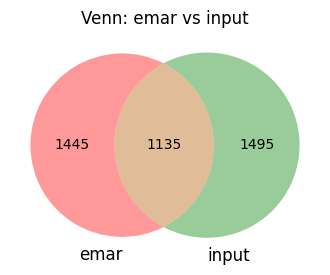

In [392]:
venn_for_dfs(dfs=[emar_ab_df, input_ab_df], key_cols=["stay_id","stay_id"], labels=["emar", "input"])

### Med_Combined (emar+ input)

In [428]:
med_combined_filt_df = pd.concat(
    [
        emar_ab_df[['subject_id', 'hadm_id', 'stay_id', 'r_med_time', 'medication','source']],
        input_ab_df[['subject_id', 'hadm_id', 'stay_id', 'r_med_time', 'medication','source']]
    ],
    ignore_index=True
)

In [430]:
hh.dxx(med_combined_filt_df)

3.1k Unique Patient IDs (3119)
3.4k Unique Admission IDs (3365)
4.1k Unique ICU Stay IDs (4075)
281.7k Rows, shape: (281707, 6)



,subject_id,hadm_id,stay_id,r_med_time,medication,source
dtype,int64,int64,int64,datetime64[ns],object,object
NotNA | NA,281707 | 0,281707 | 0,281707 | 0,281707 | 0,281707 | 0,281707 | 0
nunique,3119,3365,4075,15702,33,2
0,11128531,21303739,38877240,2157-03-20 23:27:00,cefepime,EMAR
1,11128531,21303739,38877240,2157-03-20 23:27:00,cefepime,EMAR
2,11128531,21303739,38877240,2157-03-20 23:27:00,cefepime,EMAR


In [431]:
med_combined_filt_df['antibiotic'] = med_combined_filt_df['medication'].str.replace(r'\(.*?\)', '', regex=True).str.strip()


In [432]:
med_combined_filt_df['antibiotic'] = med_combined_filt_df['antibiotic'].replace(mapping)

In [434]:
# hh.parq(med_combined_filt_df,'med_combined_filtered_df')


File saved at: med_combined_filtered_df17Feb26_1653.parquet


#### checkpoint

In [53]:
med_combined_filt_df=pd.read_parquet(PARQ_DIR /"med_combined_filtered_df17Feb26_1653.parquet")

In [54]:
hh.dxx(med_combined_filt_df)

3.1k Unique Patient IDs (3119)
3.4k Unique Admission IDs (3365)
4.1k Unique ICU Stay IDs (4075)
281.7k Rows, shape: (281707, 7)



,subject_id,hadm_id,stay_id,r_med_time,medication,source,antibiotic
dtype,int64,int64,int64,datetime64[ns],object,object,object
NotNA | NA,281707 | 0,281707 | 0,281707 | 0,281707 | 0,281707 | 0,281707 | 0,281707 | 0
nunique,3119,3365,4075,15702,33,2,33
0,11128531,21303739,38877240,2157-03-20 23:27:00,cefepime,EMAR,cefepime
1,11128531,21303739,38877240,2157-03-20 23:27:00,cefepime,EMAR,cefepime
2,11128531,21303739,38877240,2157-03-20 23:27:00,cefepime,EMAR,cefepime


In [55]:
med_combined_filt_df.source.value_counts()

source
EMAR     179050
INPUT    102657
Name: count, dtype: int64

In [56]:
med_combined_filt_df= (med_combined_filt_df.drop_duplicates())

In [57]:
med_combined_filt_df.source.value_counts()


source
INPUT    10137
EMAR      9469
Name: count, dtype: int64

In [58]:
med_combined_filt_df.head(4)


,subject_id,hadm_id,stay_id,r_med_time,medication,source,antibiotic
0,11128531,21303739,38877240,2157-03-20 23:27:00,cefepime,EMAR,cefepime
32,11926195,22063735,33520101,2177-10-23 09:11:00,vancomycin,EMAR,vancomycin
46,11339076,22370472,34198444,2125-04-24 11:35:00,cefepime,EMAR,cefepime
54,11471705,29497940,34076052,2182-09-28 12:00:00,vancomycin,EMAR,vancomycin


<Axes: >

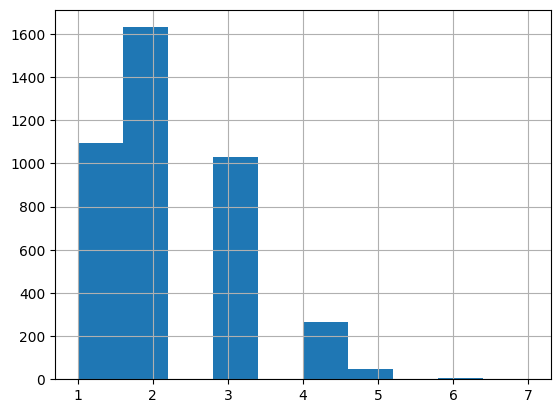

In [59]:
med_combined_filt_df.groupby('stay_id').antibiotic.nunique().hist()

### Feature medication 

In [60]:
#get only the first stay per admission

In [61]:
med_combined_filt_df=med_combined_filt_df.sort_values(by='stay_id')

In [62]:
med_combined_filt_df.head()

,subject_id,hadm_id,stay_id,r_med_time,medication,source,antibiotic
60647,11027822,21550895,30004232,2135-07-31 21:16:00,vancomycin,EMAR,vancomycin
85118,11027822,21550895,30004232,2135-08-01 09:15:00,vancomycin,EMAR,vancomycin
141382,18730522,21463350,30004391,2153-09-05 15:24:00,tobramycin,EMAR,tobramycin
270180,18730522,21463350,30004391,2153-09-05 15:27:00,tobramycin,INPUT,tobramycin
270191,18730522,21463350,30004391,2153-09-06 12:46:00,meropenem,INPUT,meropenem


In [63]:
hh.dx(med_combined_filt_df)

3.1k Unique Patient IDs (3119)
3.4k Unique Admission IDs (3365)
4.1k Unique ICU Stay IDs (4075)
19.6k Rows, shape: (19606, 7)



In [64]:
med_combined_filt_freq_df= filter_meds_by_frequency(med_combined_filt_df,id_col='stay_id',med_col='antibiotic',time_col='r_med_time',min_days=2,min_count=2)

In [65]:
hh.dx(med_combined_filt_freq_df)

2.5k Unique Patient IDs (2455)
2.6k Unique Admission IDs (2629)
3.1k Unique ICU Stay IDs (3131)
16.4k Rows, shape: (16364, 7)



<Axes: >

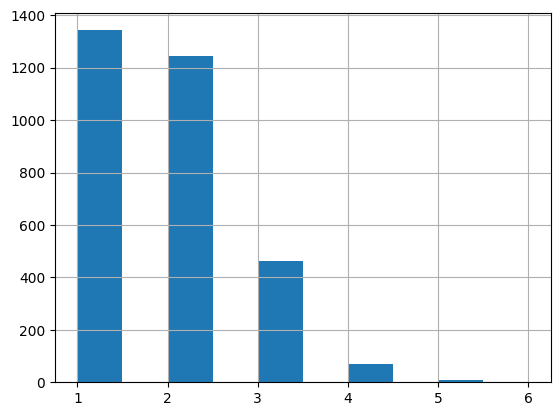

In [66]:
med_combined_filt_freq_df.groupby('stay_id')['antibiotic'].nunique().hist()

In [67]:
med_combined_sort_filt_freq_df= med_combined_filt_freq_df.sort_values(['stay_id', 'r_med_time'])

In [68]:
first_antibiotic_df=med_combined_sort_filt_freq_df.groupby('stay_id',as_index=False).first()

In [69]:
first_antibiotic_df

,stay_id,subject_id,hadm_id,r_med_time,medication,source,antibiotic
0,30004232,11027822,21550895,2135-07-31 21:16:00,vancomycin,EMAR,vancomycin
1,30004391,18730522,21463350,2153-09-05 15:24:00,tobramycin,EMAR,tobramycin
2,30006983,18756985,21715366,2159-10-12 04:30:00,piperacillin,INPUT,piperacillin
3,30016351,10600153,26100320,2126-11-06 17:19:00,ceftriaxone,EMAR,ceftriaxone
4,30023732,12002285,20686506,2191-12-28 09:43:00,vancomycin,EMAR,vancomycin
...,...,...,...,...,...,...,...
3126,39986786,19962126,21472938,2145-02-21 15:37:00,cefepime,EMAR,cefepime
3127,39988378,13992510,20612971,2174-04-17 23:42:00,meropenem,EMAR,meropenem
3128,39995213,13534199,23907399,2127-12-11 17:17:00,vancomycin,EMAR,vancomycin
3129,39996044,15952397,24449420,2164-12-11 02:00:00,cefepime,INPUT,cefepime


In [70]:
# hh.parq(first_antibiotic_df, 'first_antibiotic_df_')

File saved at: first_antibiotic_df_17Feb26_1734.parquet


In [71]:
first_antibiotic_df= hh.load_data('./parq/first_antibiotic_df_17Feb26_1734.parquet')

In [252]:
med_features = (
    med_combined_sort_filt_freq_df
        .assign(value=1)
        .pivot_table(
            index='stay_id',
            columns='antibiotic',
            values='value',
            fill_value=0
        )
        .reset_index()
)


In [253]:
med_features

antibiotic,stay_id,amikacin,ampicillin,ampicillin sulbactam,azithromycin,aztreonam,cefazolin,cefepime,ceftaroline,ceftazidime,...,nafcillin,penicillin g,piperacillin,piperacillin tazo,rifampin,tigecycline,tobramycin,trimethoprim sulfa,valgancyclovir,vancomycin
0,30000484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,30003598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,30004232,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,30004391,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,30004823,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6412,39995735,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6413,39996044,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6414,39997710,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6415,39999168,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Combine AST and Medication Features df

#### merge 1

In [72]:
hh.dxx(first_antibiotic_df)

2.5k Unique Patient IDs (2455)
2.6k Unique Admission IDs (2629)
3.1k Unique ICU Stay IDs (3131)
3.1k Rows, shape: (3131, 7)



,stay_id,subject_id,hadm_id,r_med_time,medication,source,antibiotic
dtype,int64,int64,int64,datetime64[ns],object,object,object
NotNA | NA,3131 | 0,3131 | 0,3131 | 0,3131 | 0,3131 | 0,3131 | 0,3131 | 0
nunique,3131,2455,2629,2693,28,2,28
0,30004232,11027822,21550895,2135-07-31 21:16:00,vancomycin,EMAR,vancomycin
1,30004391,18730522,21463350,2153-09-05 15:24:00,tobramycin,EMAR,tobramycin
2,30006983,18756985,21715366,2159-10-12 04:30:00,piperacillin,INPUT,piperacillin


In [73]:
hh.dxx(ast_first_df)

4.1k Unique Patient IDs (4079)
4.4k Unique Admission IDs (4426)
5.9k Unique ICU Stay IDs (5914)
58.4k Rows, shape: (58417, 20)



,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments,antibiotic,susceptible
dtype,int64,int64,int64,object,object,datetime64[ns],datetime64[ns],float64,int64,datetime64[ns],datetime64[ns],object,object,object,object,object,float64,object,object,int64
NotNA | NA,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,58417 | 0,55883 | 2534,36433 | 21984,58417 | 0,58417 | 0
nunique,4079,4426,5914,14,14,5914,5914,5900,43909,4130,4426,29,14,109,41,2,24,44,41,2
0,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5141,2133-10-01 00:00:00,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,trimethoprim sulfa,S,1.000000,None,trimethoprim sulfa,1
1,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5142,2133-10-01 00:00:00,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,nitrofurantoin,R,128.000000,None,nitrofurantoin,0
2,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5143,2133-10-01 00:00:00,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,gentamicin,S,1.000000,None,gentamicin,1


In [123]:
ast_first_dff=ast_first_df[["subject_id", "hadm_id", "stay_id", "antibiotic","charttime","interpretation"]]

In [124]:
ast_first_dff.rename(columns={"charttime":"r_ast_charttime"},inplace=True)

/var/folders/83/nr7h56f573z_vnkxbhjqb9tc0000gr/T/ipykernel_45659/812250717.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ast_first_dff.rename(columns={"charttime":"r_ast_charttime"},inplace=True)


##### Combining medication and ast results

In [126]:
first_med_ast_results_df = first_antibiotic_df.merge(
    ast_first_dff,
    left_on=["subject_id", "hadm_id", "stay_id", "antibiotic"],
    right_on=["subject_id", "hadm_id", "stay_id", "antibiotic"],
    how="inner",
    
)
     

In [127]:
hh.dx(first_med_ast_results_df)

867 Unique Patient IDs (867)
920 Unique Admission IDs (920)
1.1k Unique ICU Stay IDs (1094)
1.3k Rows, shape: (1304, 9)



In [128]:
first_med_ast_results_df= first_med_ast_results_df.drop_duplicates()

In [129]:
hh.dx(first_med_ast_results_df)

867 Unique Patient IDs (867)
920 Unique Admission IDs (920)
1.1k Unique ICU Stay IDs (1094)
1.1k Rows, shape: (1131, 9)



In [133]:
pd.set_option('display.max_rows',None)

In [141]:
first_med_ast_results_df=first_med_ast_results_df[~(first_med_ast_results_df.duplicated(subset="stay_id", keep=False))]#.groupby('stay_id').medication.nunique().hist()


In [142]:
hh.dx(first_med_ast_results_df)

843 Unique Patient IDs (843)
889 Unique Admission IDs (889)
1.1k Unique ICU Stay IDs (1057)
1.1k Rows, shape: (1057, 9)



In [80]:
first_med_ast_results_df.antibiotic.unique()

array(['vancomycin', 'tobramycin', 'ampicillin sulbactam', 'meropenem',
       'ceftriaxone', 'cefazolin', 'cefepime', 'piperacillin tazo',
       'daptomycin', 'gentamicin', 'ceftazidime', 'clindamycin',
       'ciprofloxacin', 'levofloxacin', 'imipenem', 'ampicillin',
       'linezolid', 'piperacillin', 'rifampin'], dtype=object)

In [81]:
first_med_ast_results_df.medication.unique()


array(['vancomycin', 'tobramycin', 'ampicillin sulbactam (unasyn)',
       'meropenem', 'ceftriaxone', 'cefazolin', 'cefepime',
       'piperacillin tazobactam (zosyn)', 'daptomycin', 'gentamicin',
       'ceftazidime', 'clindamycin', 'ciprofloxacin', 'levofloxacin',
       'imipenem cilastatin', 'ampicillin', 'linezolid', 'piperacillin',
       'rifampin'], dtype=object)

In [484]:
first_med_ast_results_df

,stay_id,subject_id,hadm_id,r_med_time,medication,source,antibiotic,r_ast_charttime
0,30004232,11027822,21550895,2135-07-31 21:16:00,vancomycin,EMAR,vancomycin,2135-07-31 14:00:00
1,30004391,18730522,21463350,2153-09-05 15:24:00,tobramycin,EMAR,tobramycin,2153-09-05 14:48:00
2,30036944,16560909,23278120,2180-11-04 00:00:00,ampicillin sulbactam (unasyn),INPUT,ampicillin sulbactam,2180-11-03 23:39:00
3,30037325,17232630,29523740,2144-03-22 07:19:00,meropenem,EMAR,meropenem,2144-03-22 01:55:00
4,30038172,19573124,29652097,2172-02-06 02:04:00,ceftriaxone,EMAR,ceftriaxone,2172-02-06 00:09:00
...,...,...,...,...,...,...,...,...
1298,39942998,12067437,24073863,2195-09-18 12:04:00,piperacillin tazobactam (zosyn),INPUT,piperacillin tazo,2195-09-18 10:19:00
1299,39947325,10843130,24390282,2177-12-09 08:50:00,vancomycin,INPUT,vancomycin,2177-12-08 21:35:00
1300,39966562,12031993,26724853,2155-12-22 07:58:00,vancomycin,INPUT,vancomycin,2155-12-22 07:14:00
1302,39971212,19049931,21831426,2198-11-26 13:24:00,meropenem,EMAR,meropenem,2198-11-26 11:24:00


In [144]:
# hh.parq(first_med_ast_results_df,'first_med_ast_results_df_')

In [145]:
first_med_ast_results_df = hh.load_data('./parq/first_med_ast_results_df_17Feb26_1813.parquet')

#### merge 2

In [254]:
ast_features.head(2)

antibiotic,stay_id,amikacin,ampicillin,ampicillin sulbactam,aztreonam,caspofungin,cefazolin,cefepime,cefiderocol,ceftaroline,...,oxacillin,penicillin g,piperacillin,piperacillin tazo,rifampin,tetracycline,tobramycin,trimethoprim sulfa,vancomycin,voriconzaole
0,30000153,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,30000484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [255]:
med_features.head(2)

antibiotic,stay_id,amikacin,ampicillin,ampicillin sulbactam,azithromycin,aztreonam,cefazolin,cefepime,ceftaroline,ceftazidime,...,nafcillin,penicillin g,piperacillin,piperacillin tazo,rifampin,tigecycline,tobramycin,trimethoprim sulfa,valgancyclovir,vancomycin
0,30000484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,30003598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [256]:
ast_features.columns

Index(['stay_id', 'amikacin', 'ampicillin', 'ampicillin sulbactam',
       'aztreonam', 'caspofungin', 'cefazolin', 'cefepime', 'cefiderocol',
       'ceftaroline', 'ceftazidime', 'ceftazidime avibactam',
       'ceftolozane tazobactam', 'ceftriaxone', 'cefuroxime', 'ciprofloxacin',
       'clindamycin', 'daptomycin', 'eravacycline', 'ertapenem',
       'erythromycin', 'fluconazole', 'gentamicin', 'imipenem',
       'imipenem relebactam', 'levofloxacin', 'linezolid', 'meropenem',
       'meropenem vaborbactam', 'micafungin', 'minocycline', 'nitrofurantoin',
       'oxacillin', 'penicillin g', 'piperacillin', 'piperacillin tazo',
       'rifampin', 'tetracycline', 'tobramycin', 'trimethoprim sulfa',
       'vancomycin', 'voriconzaole'],
      dtype='object', name='antibiotic')

In [257]:
med_features.columns

Index(['stay_id', 'amikacin', 'ampicillin', 'ampicillin sulbactam',
       'azithromycin', 'aztreonam', 'cefazolin', 'cefepime', 'ceftaroline',
       'ceftazidime', 'ceftriaxone', 'ciprofloxacin', 'clindamycin',
       'colistin', 'daptomycin', 'doxycycline', 'ertapenem', 'erythromycin',
       'gancyclovir', 'gentamicin', 'imipenem', 'keflex', 'levofloxacin',
       'linezolid', 'meropenem', 'metronidazole', 'moxifloxacin', 'nafcillin',
       'penicillin g', 'piperacillin', 'piperacillin tazo', 'rifampin',
       'tigecycline', 'tobramycin', 'trimethoprim sulfa', 'valgancyclovir',
       'vancomycin'],
      dtype='object', name='antibiotic')

In [260]:
features_combined = med_features.merge(
    ast_features,
    on='stay_id',
    suffixes=('_given', '_susceptible'),
    how='inner'
)


In [261]:
features_combined

antibiotic,stay_id,amikacin_given,ampicillin_given,ampicillin sulbactam_given,azithromycin,aztreonam_given,cefazolin_given,cefepime_given,ceftaroline_given,ceftazidime_given,...,oxacillin,penicillin g_susceptible,piperacillin_susceptible,piperacillin tazo_susceptible,rifampin_susceptible,tetracycline,tobramycin_susceptible,trimethoprim sulfa_susceptible,vancomycin_susceptible,voriconzaole
0,30000484,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,30003598,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,30004232,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
3,30004391,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,30004823,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5669,39995213,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
5670,39995735,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
5671,39996044,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5672,39999168,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


In [263]:
given_cols = [c for c in features_combined.columns if c.endswith('_given')]
sus_cols   = [c.replace('_given','_susceptible') for c in given_cols]

features_combined[given_cols] = (features_combined[given_cols].fillna(0).astype(int))

features_combined[sus_cols] = (features_combined[sus_cols] .fillna(0) .astype(int))

features_combined['appropriate'] = ((features_combined[given_cols].values & features_combined[sus_cols].values).any(axis=1).astype(int))


In [267]:
pd.set_option('display.max_columns',None)

In [268]:
features_combined

antibiotic,stay_id,amikacin_given,ampicillin_given,ampicillin sulbactam_given,azithromycin,aztreonam_given,cefazolin_given,cefepime_given,ceftaroline_given,ceftazidime_given,ceftriaxone_given,ciprofloxacin_given,clindamycin_given,colistin,daptomycin_given,doxycycline,ertapenem_given,erythromycin_given,gancyclovir,gentamicin_given,imipenem_given,keflex,levofloxacin_given,linezolid_given,meropenem_given,metronidazole,moxifloxacin,nafcillin,penicillin g_given,piperacillin_given,piperacillin tazo_given,rifampin_given,tigecycline,tobramycin_given,trimethoprim sulfa_given,valgancyclovir,vancomycin_given,amikacin_susceptible,ampicillin_susceptible,ampicillin sulbactam_susceptible,aztreonam_susceptible,caspofungin,cefazolin_susceptible,cefepime_susceptible,cefiderocol,ceftaroline_susceptible,ceftazidime_susceptible,ceftazidime avibactam,ceftolozane tazobactam,ceftriaxone_susceptible,cefuroxime,ciprofloxacin_susceptible,clindamycin_susceptible,daptomycin_susceptible,eravacycline,ertapenem_susceptible,erythromycin_susceptible,fluconazole,gentamicin_susceptible,imipenem_susceptible,imipenem relebactam,levofloxacin_susceptible,linezolid_susceptible,meropenem_susceptible,meropenem vaborbactam,micafungin,minocycline,nitrofurantoin,oxacillin,penicillin g_susceptible,piperacillin_susceptible,piperacillin tazo_susceptible,rifampin_susceptible,tetracycline,tobramycin_susceptible,trimethoprim sulfa_susceptible,vancomycin_susceptible,voriconzaole,appropriate
0,30000484,0,0,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0.0,0,0,0.0,1,0,0,0.0,0.0,0.0,0,1,1,0,0.0,1,0,0.0,1,0,0,0,0,0.0,0,0,0.0,0,0,0.0,0.0,0,0.0,0,0,0,0.0,0,0,0.0,0,0,0.0,0,1,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0,0,0,0.0,0
1,30003598,0,0,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0.0,0,0,0.0,0,1,0,0.0,0.0,0.0,0,1,1,0,0.0,0,0,0.0,0,0,0,0,0,0.0,0,0,0.0,0,0,0.0,0.0,0,0.0,0,0,0,0.0,0,0,0.0,1,0,0.0,0,0,1,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,1,0,0,0.0,0
2,30004232,0,0,0,0.0,0,0,1,0,0,0,0,0,0.0,1,0.0,0,0,0.0,0,0,0.0,0,1,0,1.0,0.0,0.0,0,0,0,0,0.0,0,0,0.0,1,0,0,0,0,0.0,0,1,0.0,0,1,0.0,0.0,1,0.0,1,1,0,0.0,0,1,0.0,1,0,0.0,1,0,1,0.0,0.0,0.0,0.0,0.0,1,0,1,0,0.0,1,1,1,0.0,1
3,30004391,0,0,0,0.0,0,0,1,0,0,0,0,0,0.0,0,0.0,0,0,0.0,0,0,0.0,0,0,1,0.0,0.0,0.0,0,0,0,0,0.0,1,0,0.0,1,0,0,1,0,0.0,1,1,0.0,0,1,0.0,0.0,1,0.0,1,0,0,0.0,0,0,0.0,1,0,0.0,0,0,1,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0.0,1,1,0,0.0,1
4,30004823,0,0,0,1.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0,0,0.0,0,0,0.0,1,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,0,0.0,1,0,0,0,0,0.0,0,0,0.0,0,0,0.0,0.0,0,0.0,0,0,0,0.0,0,0,0.0,1,0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0.0,0,0,1,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5669,39995213,0,0,0,0.0,0,0,1,0,1,0,0,0,0.0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,1.0,0.0,0.0,0,1,0,1,0.0,0,0,0.0,1,0,0,1,0,0.0,0,0,0.0,0,1,0.0,0.0,0,0.0,0,0,0,0.0,0,0,0.0,1,0,0.0,0,0,1,0.0,0.0,0.0,1.0,0.0,0,0,1,0,0.0,1,0,0,0.0,1
5670,39995735,0,0,0,0.0,0,1,0,0,0,0,0,0,0.0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0.0,0.0,0.0,0,0,0,0,0.0,0,0,0.0,1,0,0,1,0,0.0,1,1,0.0,0,1,0.0,0.0,1,0.0,1,0,0,0.0,0,0,0.0,1,0,0.0,0,0,1,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0.0,1,1,0,0.0,1
5671,39996044,0,0,0,1.0,0,0,1,0,0,0,0,0,0.0,0,0.0,0,0,1.0,0,0,0.0,1,0,0,1.0,0.0,0.0,0,0,0,0,0.0,0,0,0.0,1,1,0,0,0,0.0,0,1,0.0,0,1,0.0,0.0,0,0.0,1,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,0.0,0,0,0,0.0,1
5672,39999168,0,0,0,0.0,0,0,1,0,0,1,0,0,0.0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,1.0,0.0,0.0,0,0,0,0,0.0,0,0,0.0,1,0,0,0,0,0.0,0,1,0.0,0,1,0.0,0.0,0,0.0,0,0,0,0.0,0,0,0.0,1,0,0.0,1,0,1,0.0,0.0,0.0,0.0,1.0,0,0,1,0,1.0,1,1,0,0.0,1


In [264]:
features_combined.columns

Index(['stay_id', 'amikacin_given', 'ampicillin_given',
       'ampicillin sulbactam_given', 'azithromycin', 'aztreonam_given',
       'cefazolin_given', 'cefepime_given', 'ceftaroline_given',
       'ceftazidime_given', 'ceftriaxone_given', 'ciprofloxacin_given',
       'clindamycin_given', 'colistin', 'daptomycin_given', 'doxycycline',
       'ertapenem_given', 'erythromycin_given', 'gancyclovir',
       'gentamicin_given', 'imipenem_given', 'keflex', 'levofloxacin_given',
       'linezolid_given', 'meropenem_given', 'metronidazole', 'moxifloxacin',
       'nafcillin', 'penicillin g_given', 'piperacillin_given',
       'piperacillin tazo_given', 'rifampin_given', 'tigecycline',
       'tobramycin_given', 'trimethoprim sulfa_given', 'valgancyclovir',
       'vancomycin_given', 'amikacin_susceptible', 'ampicillin_susceptible',
       'ampicillin sulbactam_susceptible', 'aztreonam_susceptible',
       'caspofungin', 'cefazolin_susceptible', 'cefepime_susceptible',
       'cefiderocol', 

In [163]:
ab_cols = [col for col in features_combined.columns if col.endswith('_given')]

features_combined['appropriate'] = 0

for ab in ab_cols:
    ab_name = ab.replace('_given', '')
    sus_col = ab_name + '_susceptible'
    
    if sus_col in features_combined.columns:
        features_combined['appropriate'] |= (
            (features_combined[ab] == 1) &
            (features_combined[sus_col] == 1)
        )


## Lab Records

In [85]:
lab_test_hosp_icu_df= hh.load_data('./parq/lab_test_hosp_icu_df_23Jan26_2125.parquet')
hh.dx(lab_test_hosp_icu_df)

11.9k Unique Patient IDs (11864)
13.5k Unique Admission IDs (13549)
16.4k Unique ICU Stay IDs (16370)
16.2M Rows, shape: (16160654, 24)



In [86]:
ast_first_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'microevent_id', 'chartdate', 'charttime',
       'spec_type_desc', 'test_name', 'org_name', 'ab_name', 'interpretation',
       'dilution_value', 'comments', 'antibiotic', 'susceptible'],
      dtype='object')

In [87]:
lab_test_hosp_icu_df.rename(columns={'charttime':'r_lab_charttime'}, inplace=True)

In [88]:
resp_inf_cohort.columns

Index(['subject_id', 'gender', 'anchor_age', 'anchor_year', 'hadm_id',
       'hospital_admit_time', 'hospital_discharge_time', 'hospital_death_time',
       'stay_id', 'icu_admit_time', 'icu_discharge_time', 'icu_los_days',
       'admission_type', 'admission_location', 'discharge_location', 'race',
       'seq_num', 'icd_version', 'icd_code'],
      dtype='object')

In [89]:
lab_filt_df= filter_events_between_anchors(start_anchor_df=resp_inf_cohort, end_anchor_df=ast_first_df, events_df=lab_test_hosp_icu_df, id_col='stay_id',
                                           start_time_col='hospital_admit_time', end_time_col='charttime', event_time_col='r_lab_charttime')

In [90]:
hh.dx(lab_filt_df)

3.9k Unique Patient IDs (3924)
4.2k Unique Admission IDs (4226)
5.7k Unique ICU Stay IDs (5679)
32.2M Rows, shape: (32233472, 24)



In [91]:
# hh.parq(lab_filt_df,'lab_filt_anchor_df_')

File saved at: lab_filt_anchor_df_17Feb26_1740.parquet


In [92]:
lab_filt_df=hh.load_data('./parq/lab_filt_anchor_df_17Feb26_1740.parquet')

In [93]:
lab_70= lab_stats_per_patient_with_coverage(lab_filt_df,id_col= "stay_id", lab_col= "label", value_col= "valuenum",stats=["mean"],min_coverage=0.7)

In [94]:
lab_70

,stay_id,label,mean
0,30000153,Alanine Aminotransferase (ALT),15.000000
1,30000153,Anion Gap,12.166667
2,30000153,Asparate Aminotransferase (AST),62.000000
3,30000153,Base Excess,-3.333333
4,30000153,Bicarbonate,22.000000
...,...,...,...
166530,39999230,Urea Nitrogen,12.307692
166531,39999230,White Blood Cells,4.750000
166532,39999230,pCO2,35.111111
166533,39999230,pH,6.633077


### Feature Lab

In [95]:
feature_lab_df = (
    lab_70
    .pivot(index="stay_id", columns="label", values="mean")
    .reset_index()
)


In [97]:
feature_lab_df.head(3)

label,stay_id,Alanine Aminotransferase (ALT),Alkaline Phosphatase,Anion Gap,Asparate Aminotransferase (AST),Base Excess,Bicarbonate,"Bilirubin, Total","Calcium, Total",Calculated Total CO2,...,Platelet Count,Potassium,RDW,Red Blood Cells,Sodium,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2
0,30000153,15.000000,NaN,12.166667,62.000000,-3.333333,22.000000,NaN,7.916667,22.666667,...,148.333333,4.250,13.983333,2.900000,145.333333,20.333333,13.233333,44.0,7.227500,233.0
1,30000484,12.333333,75.333333,10.000000,34.333333,1.000000,27.666667,0.333333,8.133333,33.000000,...,339.666667,4.775,18.333333,2.886667,138.000000,41.333333,20.633333,59.0,7.086667,21.0
2,30003598,NaN,NaN,12.583333,NaN,NaN,24.250000,NaN,9.650000,NaN,...,334.833333,4.525,17.300000,3.226667,137.583333,46.166667,8.316667,NaN,5.500000,NaN


In [98]:
# hh.parq(feature_lab_df,'feature_lab_df_')

File saved at: feature_lab_df_17Feb26_1750.parquet


In [99]:
feature_lab_df= hh.load_data('./parq/feature_lab_df_17Feb26_1750.parquet')

## Cohort funnel

In [51]:
lab_ast_df= hh.df_subset(lab_test_hosp_icu_df,ast_df, by_col= "stay_id")
emar_ast_df= hh.df_subset(resp_emar,ast_df, by_col= "stay_id")
pres_ast_df= hh.df_subset(resp_pres,ast_df, by_col= "stay_id")
input_ast_df= hh.df_subset(resp_input,ast_df, by_col= "stay_id")

hh.dx(lab_ast_df)
hh.dx(emar_ast_df)
hh.dx(pres_ast_df)
hh.dx(input_ast_df)


4.1k Unique Patient IDs (4078)
4.4k Unique Admission IDs (4425)
5.9k Unique ICU Stay IDs (5913)
9.4M Rows, shape: (9400581, 24)

2.6k Unique Patient IDs (2559)
2.7k Unique Admission IDs (2734)
3.8k Unique ICU Stay IDs (3785)
9.8M Rows, shape: (9792833, 19)

4.1k Unique Patient IDs (4069)
4.4k Unique Admission IDs (4416)
5.9k Unique ICU Stay IDs (5904)
1.6M Rows, shape: (1556706, 23)

3.6k Unique Patient IDs (3618)
3.9k Unique Admission IDs (3941)
5.2k Unique ICU Stay IDs (5175)
2.1M Rows, shape: (2101459, 26)



In [110]:
counts_list = [364627,94458, df_resp_inf_icu_final.stay_id.nunique(), resp_micro.stay_id.nunique(),ast_first_df.stay_id.nunique(), 
               lab_filt_df.stay_id.nunique(), med_combined_filt_freq_df.stay_id.nunique(), first_med_ast_results_df.stay_id.nunique()]

In [111]:
counts_list

[364627, 94458, 16438, 15723, 5914, 5679, 3131, 1094]

In [115]:
labels_list = ["Overall Patient Count", "Overall ICU_Stay Count", "Respiratory_Infection_Cohort", "Micro_Records", "AST_Records", 
               "Lab_Records", "Antibiotic_Records","Matched_first_antibiotic_ast_records"]

In [116]:
# vv.funnel_chart_simple(data_list=counts_list, labels_list=labels_list)

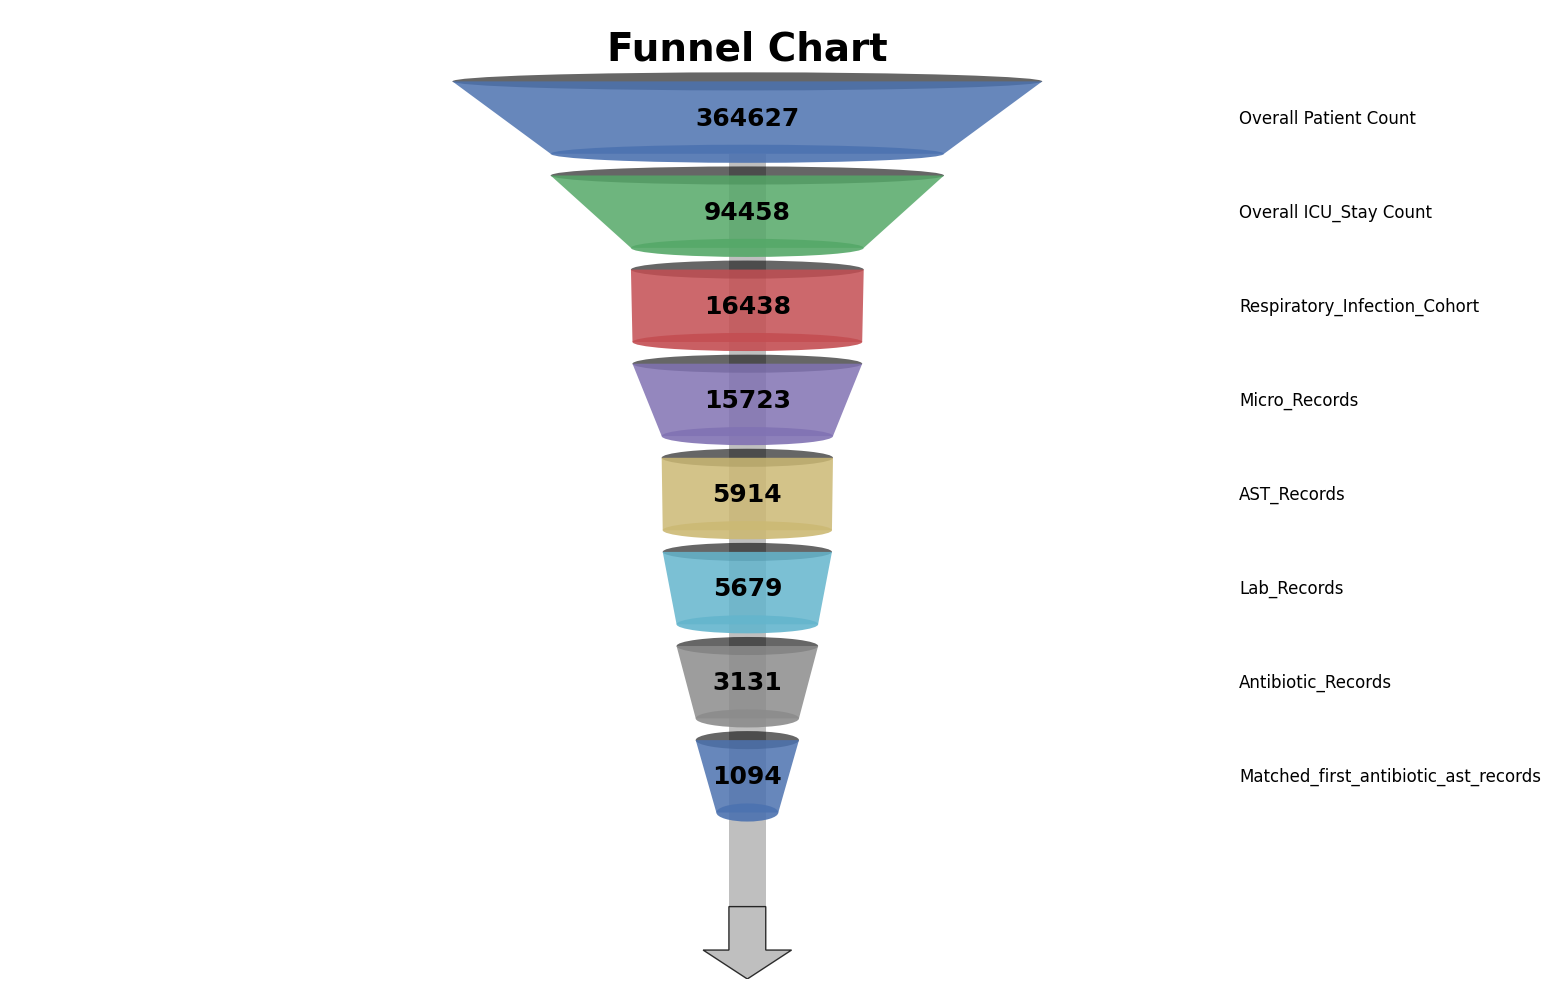

In [117]:
importlib.reload(vv)

vv.funnel_chart_3d_revised(data_list=counts_list, labels_list=labels_list)

## Final feature df

In [146]:
feature_df= feature_lab_df.drop_duplicates().merge(first_med_ast_results_df, how='inner', on='stay_id')

In [147]:
feature_df.stay_id.nunique()

1008

In [148]:
# hh.parq(feature_df, 'feature_df1_')

File saved at: feature_df1_17Feb26_1814.parquet


In [151]:
resp_inf_cohort = pd.read_parquet(PARQ_DIR / "resp_inf_cohort_23Jan26_1953.parquet")

In [153]:
hh.dxx(resp_inf_cohort)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 19)



,subject_id,gender,anchor_age,anchor_year,hadm_id,hospital_admit_time,hospital_discharge_time,hospital_death_time,stay_id,icu_admit_time,icu_discharge_time,icu_los_days,admission_type,admission_location,discharge_location,race,seq_num,icd_version,icd_code
dtype,int64,object,int64,int64,int64,datetime64[ns],datetime64[ns],datetime64[ns],int64,datetime64[ns],datetime64[ns],float64,object,object,object,object,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,4055 | 14054,18109 | 0,18109 | 0,18099 | 10,18099 | 10,18109 | 0,18109 | 0,18074 | 35,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,2,73,96,13611,13607,13598,2831,16438,16438,16430,16246,9,11,14,33,38,2,142
0,10003637,M,57,2145,28317408,2150-05-14 19:51:00,2150-05-22 16:25:00,2150-05-22 16:25:00,32824762,2150-05-16 07:30:28,2150-05-22 18:38:55,6.464201,EW EMER.,WALK-IN/SELF REFERRAL,DIED,PORTUGUESE,3,10,J1289
1,10010888,M,43,2174,20162667,2174-01-09 22:19:00,2174-01-27 16:00:00,NaT,33318955,2174-01-09 00:21:00,2174-01-18 00:48:41,9.019225,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,WHITE,2,10,J1282
2,10011938,F,57,2121,23798746,2133-08-13 09:48:00,2133-10-05 19:27:00,NaT,31780787,2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,EW EMER.,TRANSFER FROM SKILLED NURSING FACILITY,REHAB,WHITE - OTHER EUROPEAN,2,10,J15212


In [155]:
demo_df= hh.df_subset(resp_inf_cohort,isin_df=feature_df,by_col='stay_id')

In [157]:
demo_df=demo_df.drop_duplicates()

In [158]:
hh.dx(demo_df)

809 Unique Patient IDs (809)
843 Unique Admission IDs (843)
1.0k Unique ICU Stay IDs (1008)
1.2k Rows, shape: (1226, 19)



In [159]:
demo_df.columns

Index(['subject_id', 'gender', 'anchor_age', 'anchor_year', 'hadm_id',
       'hospital_admit_time', 'hospital_discharge_time', 'hospital_death_time',
       'stay_id', 'icu_admit_time', 'icu_discharge_time', 'icu_los_days',
       'admission_type', 'admission_location', 'discharge_location', 'race',
       'seq_num', 'icd_version', 'icd_code'],
      dtype='object')

In [167]:
demo_df=demo_df[['stay_id','gender', 'anchor_age','race']]

In [180]:
demo_df=demo_df.drop_duplicates()

In [181]:
demo_df.stay_id.nunique()

1008

In [185]:
demo_df.shape

(1008, 4)

In [186]:
feature_df= demo_df.merge(feature_df,how='inner', on='stay_id')

In [187]:
# hh.parq(feature_df, 'feature_df1_')

File saved at: feature_df1_17Feb26_1830.parquet


In [188]:
feature_df=hh.load_data('./parq/feature_df1_17Feb26_1830.parquet')


<!-- ## AST  df -->

# Other

## Filter ast

In [ ]:
## get organism from ast df 
ast_df.org_name.value_counts()

org_name
STAPH AUREUS COAG +        28597
ESCHERICHIA COLI           20287
PSEUDOMONAS AERUGINOSA     19364
KLEBSIELLA PNEUMONIAE      15790
ENTEROCOCCUS SP.            4273
                           ...  
PROPIONIBACTERIUM ACNES        2
CANDIDA PARAPSILOSIS           1
MORAXELLA CATARRHALIS          1
YEAST                          1
CANDIDA DUBLINIENSIS           1
Name: count, Length: 136, dtype: int64

In [ ]:
ast_df.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,microevent_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,interpretation,dilution_value,comments
4,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5141,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,TRIMETHOPRIM/SULFA,S,1.0,None
5,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5142,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,NITROFURANTOIN,R,128.0,None
6,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5143,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,GENTAMICIN,S,1.0,None
7,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5144,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,TOBRAMYCIN,S,1.0,None
8,10011938,23798746,31780787,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2133-08-13 09:48:53,2133-09-01 18:22:42,19.356817,5145,2133-10-01,2133-10-01 23:45:00,URINE,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,CEFTAZIDIME,S,1.0,None


In [ ]:
ast_df.subject_id.nunique()


4079

In [ ]:
ast_dff=ast_df[['stay_id','charttime','test_name','org_name','ab_name','interpretation']]

In [ ]:
ast_dff.head()

,stay_id,charttime,test_name,org_name,ab_name,interpretation
4,31780787,2133-10-01 23:45:00,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,TRIMETHOPRIM/SULFA,S
5,31780787,2133-10-01 23:45:00,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,NITROFURANTOIN,R
6,31780787,2133-10-01 23:45:00,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,GENTAMICIN,S
7,31780787,2133-10-01 23:45:00,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,TOBRAMYCIN,S
8,31780787,2133-10-01 23:45:00,REFLEX URINE CULTURE,ENTEROBACTER CLOACAE COMPLEX,CEFTAZIDIME,S


In [64]:
match_df= (med_ast_results_df[(med_ast_results_df['ab_norm_med']).str.upper()==(med_ast_results_df['ab_norm_ast']).str.upper()])


In [65]:
rem_df= (med_ast_results_df[~(med_ast_results_df['stay_id'].isin(match_df['stay_id']))])

In [2]:
hh.dx(match_df)

NameError: name 'hh' is not defined

#### checks

In [67]:
(rem_df.ab_name == rem_df.medication).sum()

np.int64(0)

In [72]:
import random
te = random.choice(rem_df.stay_id.unique())
print(te)
print(hh.df_sample(rem_df, by_col='stay_id',item=te).ab_norm_med.unique())
print(hh.df_sample(rem_df, by_col='stay_id',item=te).ab_norm_ast.unique())


32489859
['fluconazole' 'vancomycin' 'piperacillin/tazobactam(zosyn)']
[nan]
